# Basic plotting of connectivity

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd
import networkx as nx


sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 
import single_neuron_utils as sn 
import bhv_utils as bhv
import connectivity_utils as conn
from bootstrap_method import *


2025-07-19 20:05:13.579266: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-19 20:05:13.588240: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-19 20:05:13.597477: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-19 20:05:13.600242: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-19 20:05:13.608353: I tensorflow/core/platform/cpu_feature_guar

In [2]:
delay = 150
condn_phrase = 'delay'
condn_num = 150

# condn_key = f'{condn_phrase}{condn_num}'

In [3]:
# find folder names within model directory
all_models_dir = '/home/nuttidalab/Documents/renee/all_DMS_models/'

model_dirs = ld.get_immediate_subdirs(all_models_dir)
print(model_dirs)


['Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_231815', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_084645', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212818', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_011809', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_163926', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_160648', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_225459', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_165543', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_221440', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_225727', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_175711', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_174328', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_204320', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212723', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_234449', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_032739', 'Task_x

In [4]:
# choose model 0 to visualize for now
model_name = model_dirs[1] # start w a good model
model_dir = os.path.join(all_models_dir, model_name)

# find files for this delay of interest
data_files = ld.find_files_keywords(model_dir, [f'delay{delay}'])
print(data_files)

['/home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_084645/timingdata_raw_lesionuntunednull_delay150.mat', '/home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_084645/timingdata_raw_lesionuntuned_delay150.mat', '/home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_084645/neuraldata_raw_delay150.mat', '/home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_084645/neuraldata_raw_lesionuntunedpost_delay150.mat', '/home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_084645/bhvdata_raw_delay150.mat', '/home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_084645/neuraldata_raw_lesionuntunednull_delay150.mat', '/home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_08464

In [5]:
exc_ind, inh_ind = ld.get_celltype_label(model_name)

In [6]:
# neural data
importlib.reload(ld)
# lfp_data, spk_times_df, rates_data = ld.load_neural_data(model_name, condn_phrase, condn_num,
#                                                   load_LFP=False, load_spikes=False, load_rates=True)
# # behavioral data
# trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase='delay', condn_num=delay)

# # timing data
# _, times_real, fs_dict = ld.load_timing_data(model_name, condn_phrase='delay', condn_num=delay)
# times_ms, _,_ = ld.get_times_dict('ds', condn_phrase, condn_num, model_name)

# get connectivity info
connectivity_df = ld.get_connectivity_df(model_name, condn_phrase, condn_num)

## Get weights and build graph

In [9]:
# get graph weights

W = ld.get_weights(model_name, condn_phrase, condn_num)
W.shape

(200, 200)

In [7]:
def build_directed_graph(W):
    G = nx.DiGraph()
    N = W.shape[0]
    for i in range(N):
        for j in range(N):
            if W[i, j] != 0:
                G.add_edge(i, j, weight=W[j, i])
    return G

In [53]:
G = build_directed_graph(W)

### show matrix

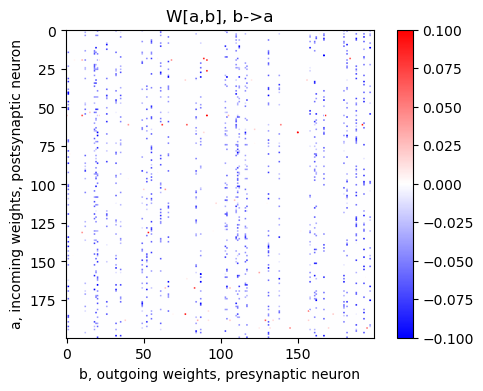

In [10]:
conn.plot_connectivity_matrix(W)

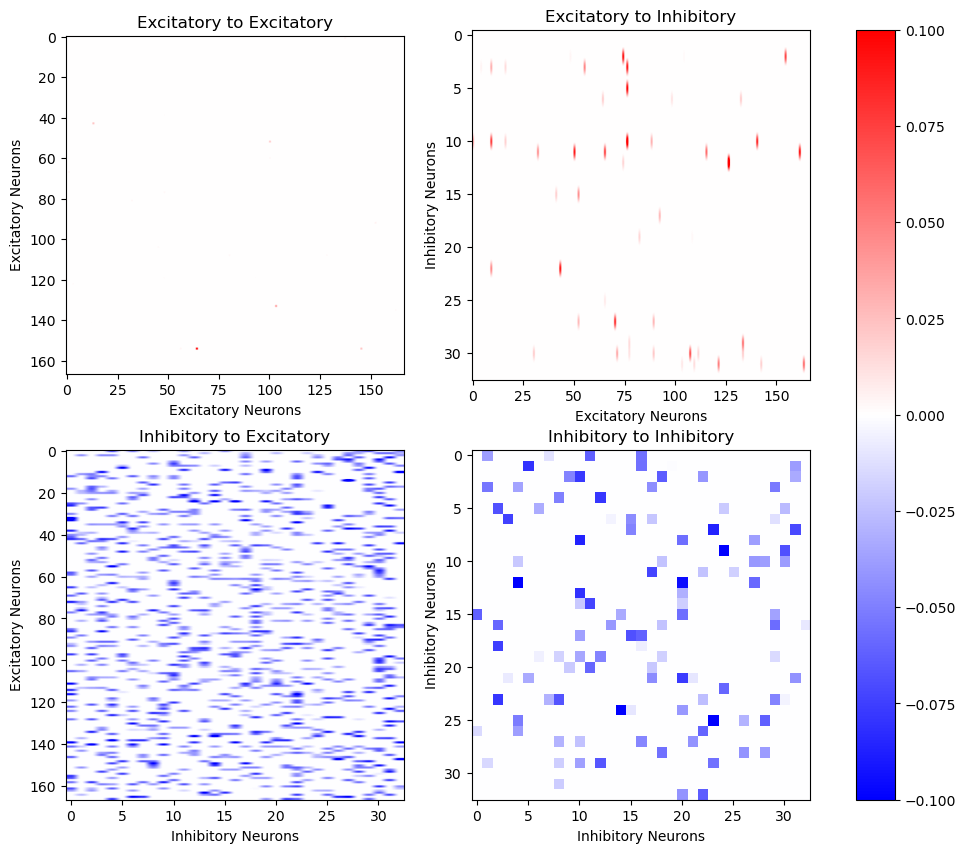

In [63]:
conn.plot_connectivity_matrix_by_type(W, exc_ind, inh_ind)

## in-degree, out-degree, clustering

### trained network connections

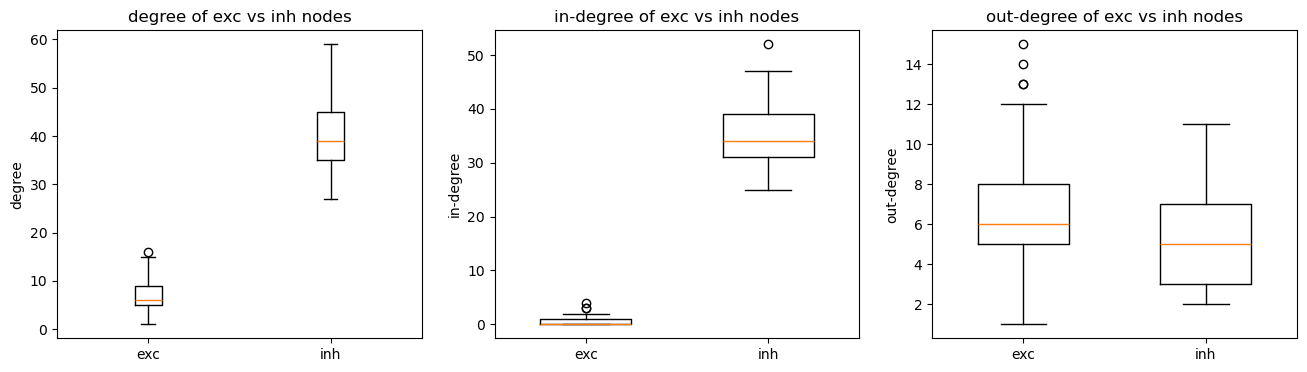

In [43]:
# get graph weights
model_num = 1
W = ld.get_weights(model_dirs[model_num])
exc_ind, inh_ind = ld.get_celltype_label(model_dirs[model_num])

# build the directed graph
G = build_directed_graph(W)
# get the degree of each node
degree_dict = dict(G.degree())
# get the in-degree of each node
in_degree_dict = dict(G.in_degree())
# get the out-degree of each node
out_degree_dict = dict(G.out_degree())


# boxplot for degree of exc versus inh nodes
types = ['exc','inh']
inds = [exc_ind, inh_ind]
degrees = []
for i, t in enumerate(types):
    degrees.append([degree_dict[j] for j in inds[i]])

fig, axs = plt.subplots(1,3,figsize=(16,4))
axs[0].boxplot(degrees, tick_labels=types)
axs[0].set_ylabel('degree')
axs[0].set_title('degree of exc vs inh nodes')

axs[1].boxplot([in_degree_dict[j] for j in exc_ind], positions=[0], widths=0.5)
axs[1].boxplot([in_degree_dict[j] for j in inh_ind], positions=[1], widths=0.5)
axs[1].set_ylabel('in-degree')
axs[1].set_title('in-degree of exc vs inh nodes')
axs[1].set_xticks([0, 1], ['exc', 'inh'])

axs[2].boxplot([out_degree_dict[j] for j in exc_ind], positions=[0], widths=0.5)
axs[2].boxplot([out_degree_dict[j] for j in inh_ind], positions=[1], widths=0.5)
axs[2].set_ylabel('out-degree')
axs[2].set_title('out-degree of exc vs inh nodes')
axs[2].set_xticks([0, 1], ['exc', 'inh'])


plt.show()


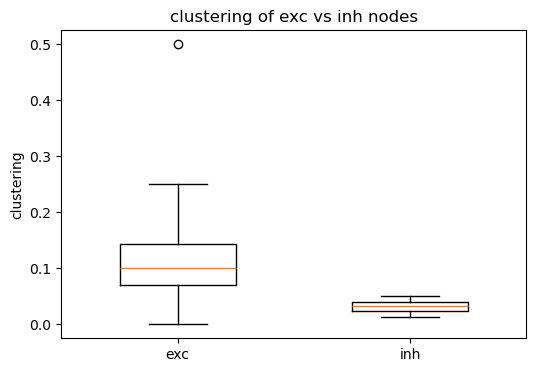

In [ ]:
# boxplot of clustering by exc/inh

clustering = nx.clustering(G)

plt.figure(figsize=(6,4))

plt.boxplot([clustering[j] for j in exc_ind], positions=[0], widths=0.5)
plt.boxplot([clustering[j] for j in inh_ind], positions=[1], widths=0.5)
plt.ylabel('clustering')
plt.title('clustering of exc vs inh nodes')
plt.xticks([0, 1], ['exc', 'inh'])
plt.show()

### generating an un-trained initial W matrix

In [28]:
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/rate')
from model import FR_RNN_dale

N = 200
net = FR_RNN_dale(N, .2, .2, np.float32(np.random.randn(N, 2)), 0, 'gaus', 1.5, True, np.float32(np.random.randn(1, N)/100))

2025-05-07 15:12:20.197646: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-07 15:12:20.203889: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-07 15:12:20.209430: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-07 15:12:20.211221: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-07 15:12:20.218107: I tensorflow/core/platform/cpu_feature_guar

Instructions for updating:
non-resource variables are not supported in the long term


In [36]:
W_init = net.W @ net.mask

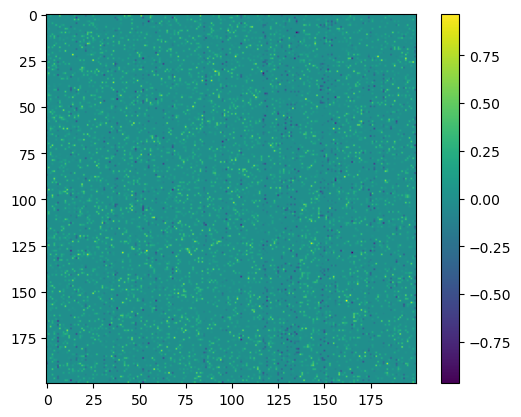

In [39]:
plt.imshow(W_init)
plt.colorbar()

In [48]:
exc_ind = np.where(net.exc == 1)[0]
inh_ind = np.where(net.exc == 0)[0]

print(exc_ind)
print(inh_ind)

[  1   2   3   4   5   7   8   9  10  11  12  14  15  17  18  19  20  22
  23  24  25  26  27  28  29  30  32  33  35  36  39  40  41  42  43  44
  45  46  47  49  50  51  53  54  56  57  58  60  61  62  64  65  66  67
  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83  84  87  88
  89  90  91  92  93  94  96  98  99 100 101 102 103 104 106 107 108 109
 110 111 112 113 114 115 116 120 121 122 123 124 126 128 131 133 137 138
 139 140 141 142 143 144 145 146 147 151 153 155 157 158 160 161 162 163
 164 166 167 168 169 170 172 173 176 178 179 180 181 183 184 185 187 188
 190 191 192 194 195 196 197 198]
[  0   6  13  16  21  31  34  37  38  48  52  55  59  63  68  85  86  95
  97 105 117 118 119 125 127 129 130 132 134 135 136 148 149 150 152 154
 156 159 165 171 174 175 177 182 186 189 193 199]


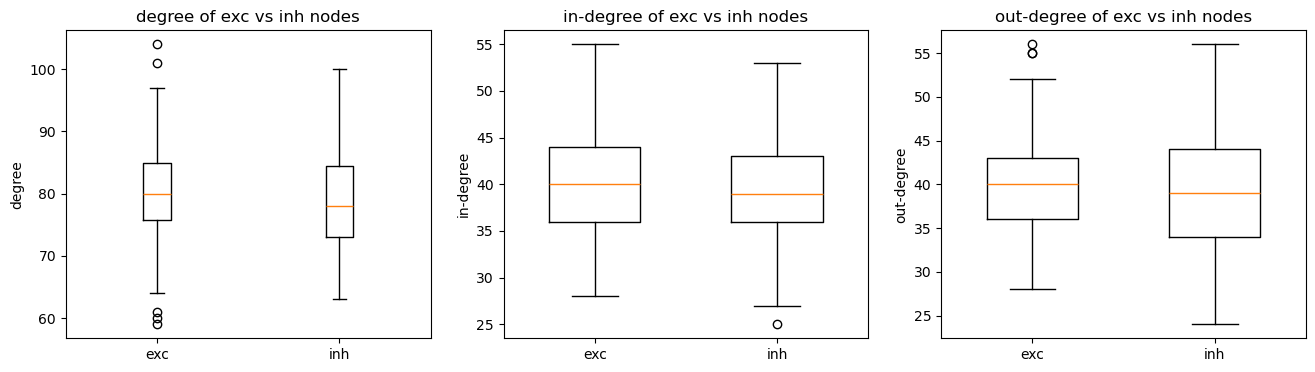

In [49]:
# get graph weights

# build the directed graph
G = build_directed_graph(W_init)
# get the degree of each node
degree_dict = dict(G.degree())
# get the in-degree of each node
in_degree_dict = dict(G.in_degree())
# get the out-degree of each node
out_degree_dict = dict(G.out_degree())


# boxplot for degree of exc versus inh nodes
types = ['exc','inh']
inds = [exc_ind, inh_ind]
degrees = []
for i, t in enumerate(types):
    degrees.append([degree_dict[j] for j in inds[i]])

fig, axs = plt.subplots(1,3,figsize=(16,4))
axs[0].boxplot(degrees, tick_labels=types)
axs[0].set_ylabel('degree')
axs[0].set_title('degree of exc vs inh nodes')

axs[1].boxplot([in_degree_dict[j] for j in exc_ind], positions=[0], widths=0.5)
axs[1].boxplot([in_degree_dict[j] for j in inh_ind], positions=[1], widths=0.5)
axs[1].set_ylabel('in-degree')
axs[1].set_title('in-degree of exc vs inh nodes')
axs[1].set_xticks([0, 1], ['exc', 'inh'])

axs[2].boxplot([out_degree_dict[j] for j in exc_ind], positions=[0], widths=0.5)
axs[2].boxplot([out_degree_dict[j] for j in inh_ind], positions=[1], widths=0.5)
axs[2].set_ylabel('out-degree')
axs[2].set_title('out-degree of exc vs inh nodes')
axs[2].set_xticks([0, 1], ['exc', 'inh'])


plt.show()


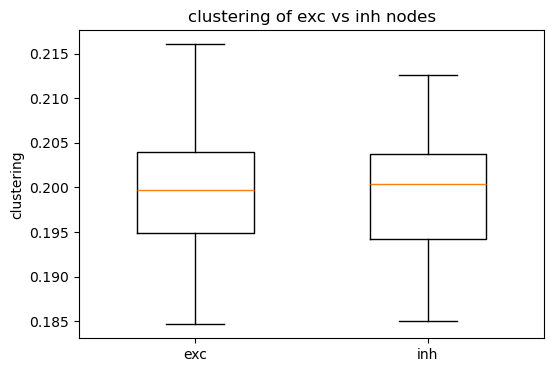

In [50]:
# boxplot of clustering by exc/inh

clustering = nx.clustering(G)

plt.figure(figsize=(6,4))

plt.boxplot([clustering[j] for j in exc_ind], positions=[0], widths=0.5)
plt.boxplot([clustering[j] for j in inh_ind], positions=[1], widths=0.5)
plt.ylabel('clustering')
plt.title('clustering of exc vs inh nodes')
plt.xticks([0, 1], ['exc', 'inh'])
plt.show()

## Number of each connection type

In [ ]:
connectivity_df.head()

,presyn_id,postsyn_id,weight,presyn_type,postsyn_type
0,0,55,0.038348,exc,inh
1,1,14,-0.061000,inh,exc
2,1,23,-0.044602,inh,exc
3,1,31,-0.070664,inh,exc
4,1,33,-0.086562,inh,exc


### trained

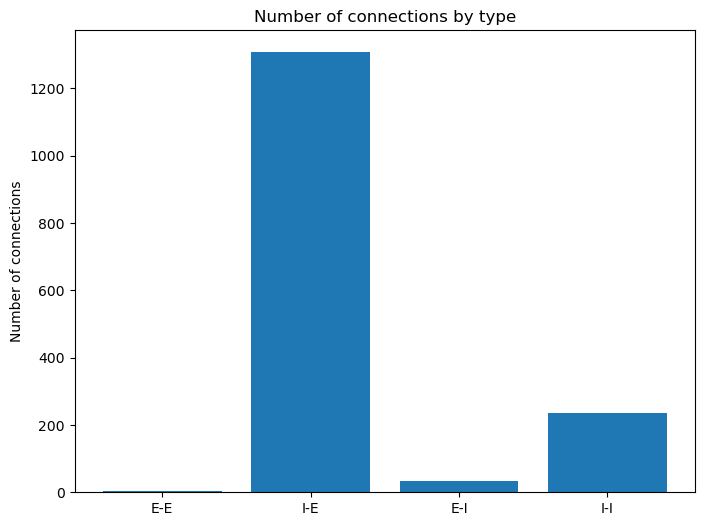

In [57]:
# plot the number of each connection type
import matplotlib.pyplot as plt

ee_mask = np.ix_(exc_ind, exc_ind)
ie_mask = np.ix_(exc_ind, inh_ind)
ei_mask = np.ix_(inh_ind, exc_ind)
ii_mask = np.ix_(inh_ind, inh_ind)

ee = W[ee_mask]
ie = W[ie_mask]
ei = W[ei_mask]
ii = W[ii_mask]

plt.figure(figsize=(8, 6))
plt.bar(['E-E', 'I-E', 'E-I', 'I-I'], [np.sum(ee != 0), np.sum(ie != 0), np.sum(ei != 0), np.sum(ii != 0)])
plt.ylabel('Number of connections')
plt.title('Number of connections by type')
plt.show()

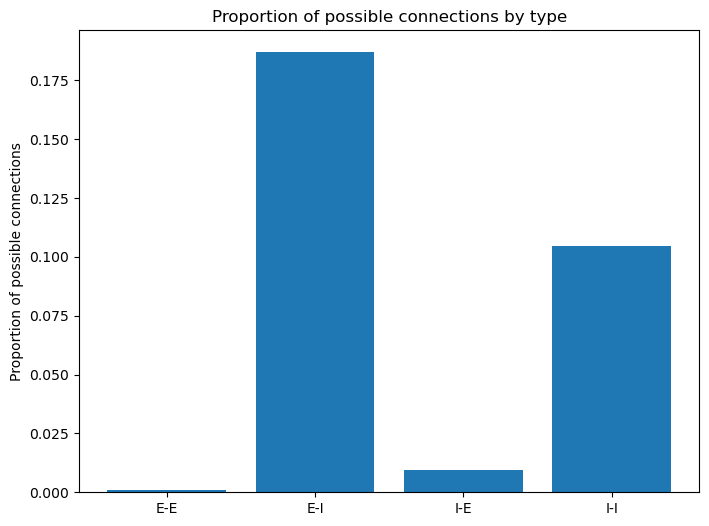

In [25]:
# plot the proportion of each connection type out of all connections

plt.figure(figsize=(8, 6))
plt.bar(['E-E', 'E-I', 'I-E', 'I-I'], [np.sum(ee != 0) / ee.size, np.sum(ie != 0) / ie.size, np.sum(ei != 0) / ei.size, np.sum(ii != 0) / ii.size])
plt.ylabel('Proportion of possible connections')
plt.title('Proportion of possible connections by type')
plt.show()


### untrained

#### from newly initialized (wrong)

In [17]:
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/rate')
from model import FR_RNN_dale

N = 200
net = FR_RNN_dale(N, .2, .2, np.float32(np.random.randn(N, 2)), 0, 'gaus', 1.5, True, np.float32(np.random.randn(1, N)/100))

Instructions for updating:
non-resource variables are not supported in the long term


In [18]:
W_init = net.W @ net.mask

In [20]:
exc_ind_init = np.where(net.exc == 1)[0]
inh_ind_init = np.where(net.exc == 0)[0]

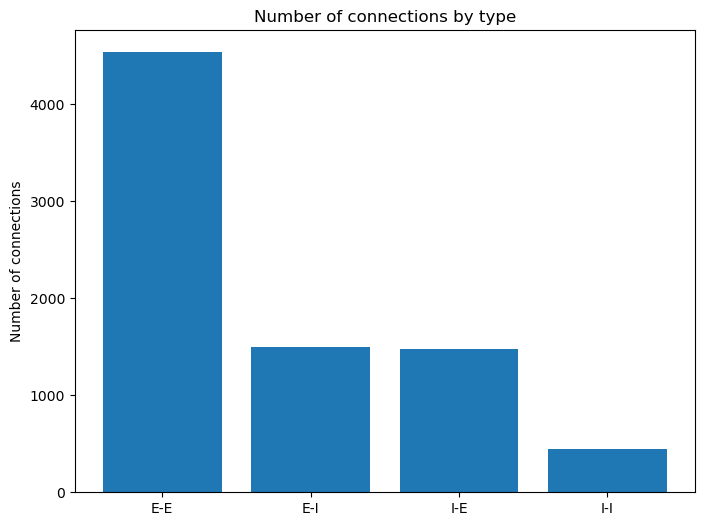

In [26]:
# plot the number of each connection type
import matplotlib.pyplot as plt

ee_mask = np.ix_(exc_ind_init, exc_ind_init)
ie_mask = np.ix_(exc_ind_init, inh_ind_init)
ei_mask = np.ix_(inh_ind_init, exc_ind_init)
ii_mask = np.ix_(inh_ind_init, inh_ind_init)

ee = W_init[ee_mask]
ie = W_init[ie_mask]
ei = W_init[ei_mask]
ii = W_init[ii_mask]

plt.figure(figsize=(8, 6))
plt.bar(['E-E', 'E-I', 'I-E', 'I-I'], [np.sum(ee != 0), np.sum(ie != 0), np.sum(ei != 0), np.sum(ii != 0)])
plt.ylabel('Number of connections')
plt.title('Number of connections by type')
plt.show()

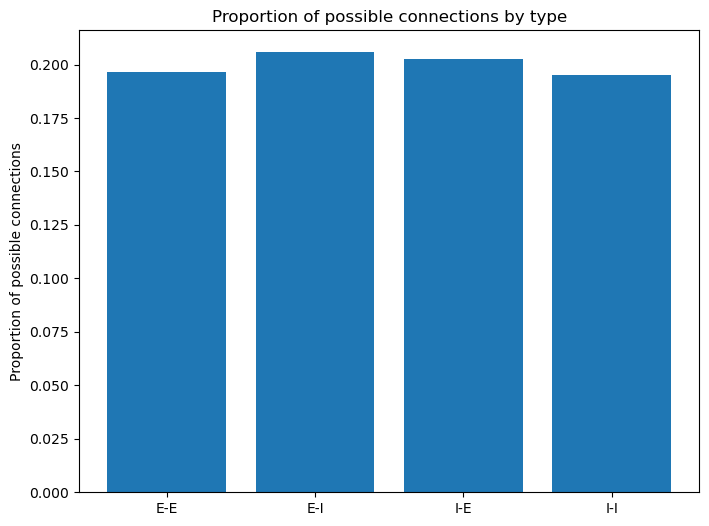

In [27]:
# plot the proportion of each connection type out of all connections

plt.figure(figsize=(8, 6))
plt.bar(['E-E', 'E-I', 'I-E', 'I-I'], [np.sum(ee != 0) / ee.size, np.sum(ie != 0) / ie.size, np.sum(ei != 0) / ei.size, np.sum(ii != 0) / ii.size])
plt.ylabel('Proportion of possible connections')
plt.title('Proportion of possible connections by type')
plt.show()


In [7]:
def get_num_connections(W, exc_ind, inh_ind):
    ee_mask = np.ix_(exc_ind, exc_ind)
    ie_mask = np.ix_(exc_ind, inh_ind)
    ei_mask = np.ix_(inh_ind, exc_ind)
    ii_mask = np.ix_(inh_ind, inh_ind)

    ee = W[ee_mask]
    ie = W[ie_mask]
    ei = W[ei_mask]
    ii = W[ii_mask]

    return np.sum(ii != 0), np.sum(ee != 0), np.sum(ei != 0), np.sum(ie != 0), 

def get_proportion_connections(W, exc_ind, inh_ind):
    ee_mask = np.ix_(exc_ind, exc_ind)
    ie_mask = np.ix_(exc_ind, inh_ind)
    ei_mask = np.ix_(inh_ind, exc_ind)
    ii_mask = np.ix_(inh_ind, inh_ind)

    ee = W[ee_mask]
    ie = W[ie_mask]
    ei = W[ei_mask]
    ii = W[ii_mask]

    return np.sum(ee != 0) / ee.size, np.sum(ii != 0) / ii.size, np.sum(ei != 0) / ei.size, np.sum(ie != 0) / ie.size

In [31]:
# plot comparing trained and untrained

trained_num = []
untrained_num = []
trained_prop = []
untrained_prop = []

for model_num in range(len(model_dirs)):
    
    # trained
    W = ld.get_weights(model_dirs[model_num], condn_num, condn_phrase)
    exc_ind, inh_ind = ld.get_celltype_label(model_dirs[model_num], condn_num, condn_phrase)
    trained_num.append(get_num_connections(W, exc_ind, inh_ind))
    trained_prop.append(get_proportion_connections(W, exc_ind, inh_ind))

    # untrained
    N = 200
    net = FR_RNN_dale(N, .2, .2, np.float32(np.random.randn(N, 2)), 0, 'gaus', 1.5, True, np.float32(np.random.randn(1, N)/100))
    W_init = net.W @ net.mask
    exc_ind_init = np.where(net.exc == 1)[0]
    inh_ind_init = np.where(net.exc == 0)[0]

    untrained_num.append(get_num_connections(W_init, exc_ind_init, inh_ind_init))
    untrained_prop.append(get_proportion_connections(W_init, exc_ind_init, inh_ind_init))
# convert to numpy arrays
trained_num = np.array(trained_num)
untrained_num = np.array(untrained_num)
trained_prop = np.array(trained_prop)
untrained_prop = np.array(untrained_prop)

In [35]:
trained_num.shape

(142, 4)

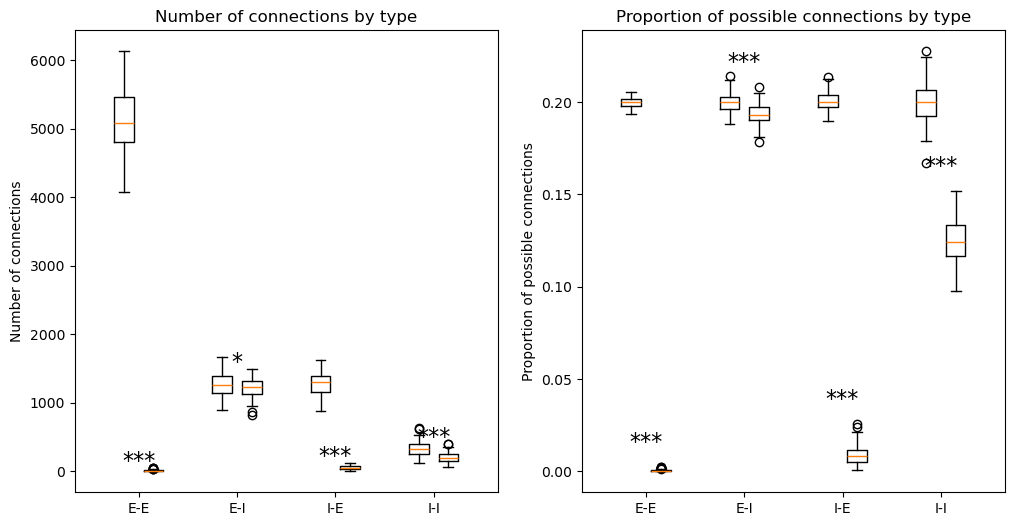

In [46]:
# plot trained vs untrained number of connections

connection_types = ['E-E', 'E-I', 'I-E', 'I-I']
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].boxplot(untrained_num, positions=np.arange(len(connection_types)), widths=0.2, label='trained')
axs[0].boxplot(trained_num, positions=np.arange(len(connection_types)) + 0.3, widths=0.2, label='untrained')
axs[0].set_xticks(np.arange(len(connection_types)) + 0.15, connection_types)
axs[0].set_ylabel('Number of connections')
axs[0].set_title('Number of connections by type')
# axs[0].legend()

axs[1].boxplot(untrained_prop, positions=np.arange(len(connection_types)), widths=0.2, label='trained')
axs[1].boxplot(trained_prop, positions=np.arange(len(connection_types)) + 0.3, widths=0.2, label='untrained')
axs[1].set_xticks(np.arange(len(connection_types)) + 0.15, connection_types)
axs[1].set_ylabel('Proportion of possible connections')
axs[1].set_title('Proportion of possible connections by type')
# axs[1].legend() 

# plot mann whitney U test results for num and proportion of connections
from scipy.stats import mannwhitneyu
p_values_num = []
p_values_prop = []
# for number of connections
for i in range(len(connection_types)):
    stat, p = mannwhitneyu(trained_num[:, i], untrained_num[:, i])
    p_values_num.append(p)
p_values_num = np.array(p_values_num)

# for proportion of connections
for i in range(len(connection_types)):
    stat, p = mannwhitneyu(trained_prop[:, i], untrained_prop[:, i])
    p_values_prop.append(p)
p_values_prop = np.array(p_values_prop)

# plot p-values as stars on top of the boxplots
for i, p in enumerate(p_values_num):
    if p < 0.001:
        axs[0].text(i+.15, np.max(trained_num[:, i]) + 0.1, '***', fontsize=16, ha='center')
    elif p < 0.01:
        axs[0].text(i+.15, np.max(trained_num[:, i]) + 0.1, '**', fontsize=16, ha='center')
    elif p < 0.05:
        axs[0].text(i+.15, np.max(trained_num[:, i]) + 0.1, '*', fontsize=16, ha='center')
    
for i, p in enumerate(p_values_prop):
    if p < 0.001:
        axs[1].text(i+.15, np.max(trained_prop[:, i]) + 0.01, '***', fontsize=16, ha='center')
    elif p < 0.01:
        axs[1].text(i+.15, np.max(trained_prop[:, i]) + 0.01, '**', fontsize=16, ha='center')
    elif p < 0.05:
        axs[1].text(i+.15, np.max(trained_prop[:, i]) + 0.01, '*', fontsize=16, ha='center')

# plt.tight_layout()

# save as eps
plt.savefig('/home/nuttidalab/Documents/renee/spikeRNN/analysis/2_clusters/2_connectivity/trained_vs_untrained_connections.eps', format='eps')

plt.show()

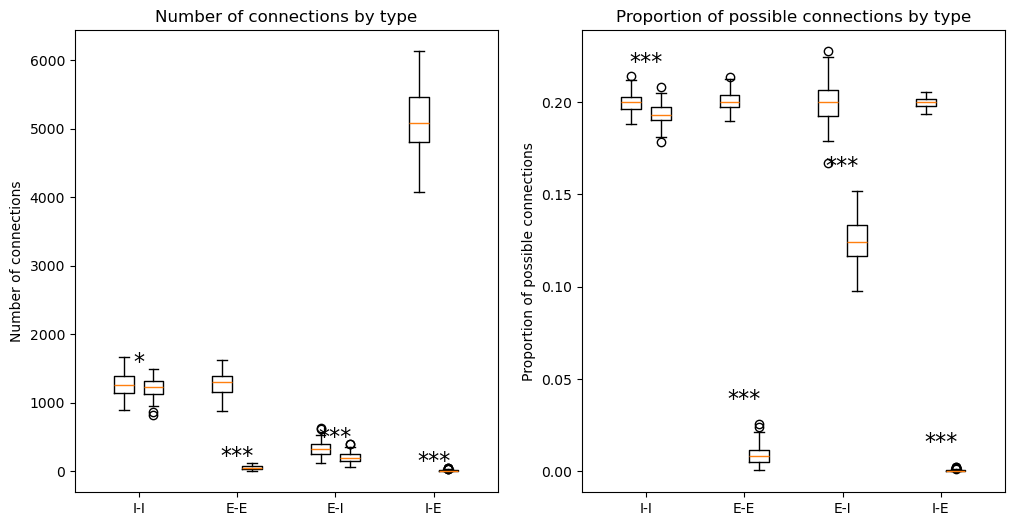

In [49]:
# plot trained vs untrained number of connections

connection_types = ['E-E', 'E-I', 'I-E', 'I-I']
connection_order = [3,0,1,2]  # order of connections to plot
# reorder the connections
trained_num = trained_num[:, connection_order]
untrained_num = untrained_num[:, connection_order]
trained_prop = trained_prop[:, connection_order]
untrained_prop = untrained_prop[:, connection_order]
connection_types = [connection_types[i] for i in connection_order]

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].boxplot(untrained_num, positions=np.arange(len(connection_types)), widths=0.2, label='trained')
axs[0].boxplot(trained_num, positions=np.arange(len(connection_types)) + 0.3, widths=0.2, label='untrained')
axs[0].set_xticks(np.arange(len(connection_types)) + 0.15, connection_types)
axs[0].set_ylabel('Number of connections')
axs[0].set_title('Number of connections by type')
# axs[0].legend()

axs[1].boxplot(untrained_prop, positions=np.arange(len(connection_types)), widths=0.2, label='trained')
axs[1].boxplot(trained_prop, positions=np.arange(len(connection_types)) + 0.3, widths=0.2, label='untrained')
axs[1].set_xticks(np.arange(len(connection_types)) + 0.15, connection_types)
axs[1].set_ylabel('Proportion of possible connections')
axs[1].set_title('Proportion of possible connections by type')
# axs[1].legend() 

# plot mann whitney U test results for num and proportion of connections
from scipy.stats import mannwhitneyu
p_values_num = []
p_values_prop = []
# for number of connections
for i in range(len(connection_types)):
    stat, p = mannwhitneyu(trained_num[:, i], untrained_num[:, i])
    p_values_num.append(p)
p_values_num = np.array(p_values_num)

# for proportion of connections
for i in range(len(connection_types)):
    stat, p = mannwhitneyu(trained_prop[:, i], untrained_prop[:, i])
    p_values_prop.append(p)
p_values_prop = np.array(p_values_prop)

# plot p-values as stars on top of the boxplots
for i, p in enumerate(p_values_num):
    if p < 0.001:
        axs[0].text(i+.15, np.max(trained_num[:, i]) + 0.1, '***', fontsize=16, ha='center')
    elif p < 0.01:
        axs[0].text(i+.15, np.max(trained_num[:, i]) + 0.1, '**', fontsize=16, ha='center')
    elif p < 0.05:
        axs[0].text(i+.15, np.max(trained_num[:, i]) + 0.1, '*', fontsize=16, ha='center')
    
for i, p in enumerate(p_values_prop):
    if p < 0.001:
        axs[1].text(i+.15, np.max(trained_prop[:, i]) + 0.01, '***', fontsize=16, ha='center')
    elif p < 0.01:
        axs[1].text(i+.15, np.max(trained_prop[:, i]) + 0.01, '**', fontsize=16, ha='center')
    elif p < 0.05:
        axs[1].text(i+.15, np.max(trained_prop[:, i]) + 0.01, '*', fontsize=16, ha='center')

# plt.tight_layout()

# save as eps
plt.savefig('/home/nuttidalab/Documents/renee/spikeRNN/analysis/2_clusters/2_connectivity/trained_vs_untrained_connections.eps', format='eps')

plt.show()

In [50]:
p_values_prop

array([2.69187073e-18, 4.47498999e-48, 4.47548989e-48, 4.47461510e-48])

#### for w0 instead of random init networks

In [11]:
def get_num_connections(W, exc_ind, inh_ind):
    ee_mask = np.ix_(exc_ind, exc_ind)
    ie_mask = np.ix_(exc_ind, inh_ind)
    ei_mask = np.ix_(inh_ind, exc_ind)
    ii_mask = np.ix_(inh_ind, inh_ind)

    ee = W[ee_mask]
    ie = W[ie_mask]
    ei = W[ei_mask]
    ii = W[ii_mask]

    return np.sum(ii != 0), np.sum(ee != 0), np.sum(ei != 0), np.sum(ie != 0), 

def get_proportion_connections(W, exc_ind, inh_ind):
    ee_mask = np.ix_(exc_ind, exc_ind)
    ie_mask = np.ix_(exc_ind, inh_ind)
    ei_mask = np.ix_(inh_ind, exc_ind)
    ii_mask = np.ix_(inh_ind, inh_ind)

    ee = W[ee_mask]
    ie = W[ie_mask]
    ei = W[ei_mask]
    ii = W[ii_mask]

    return np.sum(ii != 0) / ii.size, np.sum(ee != 0) / ee.size, np.sum(ei != 0) / ei.size, np.sum(ie != 0) / ie.size

In [12]:
# plot comparing trained and untrained

importlib.reload(ld)

trained_num = []
untrained_num = []
trained_prop = []
untrained_prop = []

for model_num in range(len(model_dirs)):
    
    # trained
    W = ld.get_weights(model_dirs[model_num], condn_num, condn_phrase)
    exc_ind, inh_ind = ld.get_celltype_label(model_dirs[model_num], condn_num, condn_phrase)
    trained_num.append(get_num_connections(W, exc_ind, inh_ind))
    trained_prop.append(get_proportion_connections(W, exc_ind, inh_ind))

    # untrained
    W_init = ld.get_weights_init(model_dirs[model_num], condn_num, condn_phrase)

    untrained_num.append(get_num_connections(W_init, exc_ind, inh_ind))
    untrained_prop.append(get_proportion_connections(W_init, exc_ind, inh_ind))
# convert to numpy arrays
trained_num = np.array(trained_num)
untrained_num = np.array(untrained_num)
trained_prop = np.array(trained_prop)
untrained_prop = np.array(untrained_prop)

In [ ]:
trained_num.shape

# ii, ee, ei, ie

(142, 4)

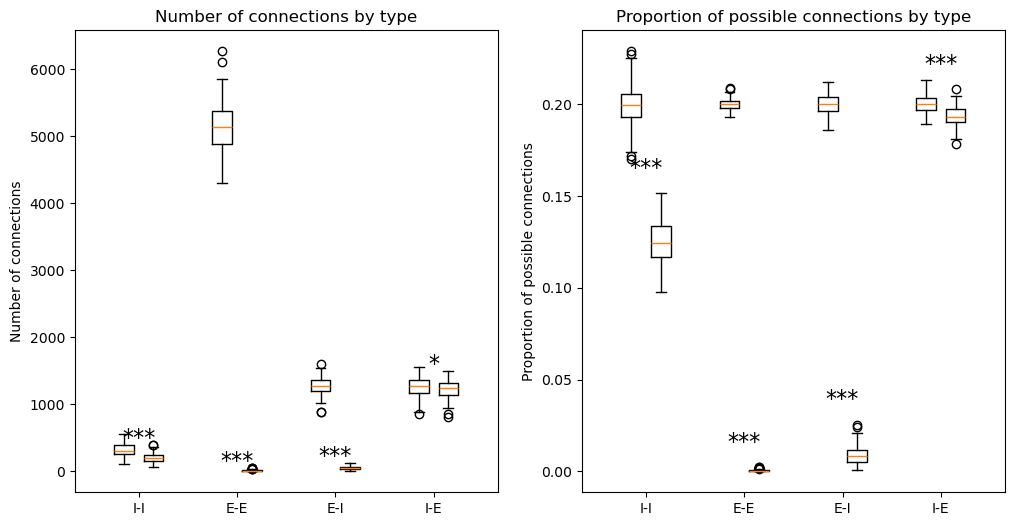

In [13]:
# plot trained vs untrained number of connections

connection_types = ['I-I', 'E-E', 'E-I', 'I-E']

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].boxplot(untrained_num, positions=np.arange(len(connection_types)), widths=0.2, label='trained')
axs[0].boxplot(trained_num, positions=np.arange(len(connection_types)) + 0.3, widths=0.2, label='untrained')
axs[0].set_xticks(np.arange(len(connection_types)) + 0.15, connection_types)
axs[0].set_ylabel('Number of connections')
axs[0].set_title('Number of connections by type')
# axs[0].legend()

axs[1].boxplot(untrained_prop, positions=np.arange(len(connection_types)), widths=0.2, label='trained')
axs[1].boxplot(trained_prop, positions=np.arange(len(connection_types)) + 0.3, widths=0.2, label='untrained')
axs[1].set_xticks(np.arange(len(connection_types)) + 0.15, connection_types)
axs[1].set_ylabel('Proportion of possible connections')
axs[1].set_title('Proportion of possible connections by type')
# axs[1].legend() 

# plot mann whitney U test results for num and proportion of connections
from scipy.stats import mannwhitneyu
p_values_num = []
p_values_prop = []
# for number of connections
for i in range(len(connection_types)):
    stat, p = mannwhitneyu(trained_num[:, i], untrained_num[:, i])
    p_values_num.append(p)
p_values_num = np.array(p_values_num)

# for proportion of connections
for i in range(len(connection_types)):
    stat, p = mannwhitneyu(trained_prop[:, i], untrained_prop[:, i])
    p_values_prop.append(p)
p_values_prop = np.array(p_values_prop)

# plot p-values as stars on top of the boxplots
for i, p in enumerate(p_values_num):
    if p < 0.001:
        axs[0].text(i+.15, np.max(trained_num[:, i]) + 0.1, '***', fontsize=16, ha='center')
    elif p < 0.01:
        axs[0].text(i+.15, np.max(trained_num[:, i]) + 0.1, '**', fontsize=16, ha='center')
    elif p < 0.05:
        axs[0].text(i+.15, np.max(trained_num[:, i]) + 0.1, '*', fontsize=16, ha='center')
    
for i, p in enumerate(p_values_prop):
    if p < 0.001:
        axs[1].text(i+.15, np.max(trained_prop[:, i]) + 0.01, '***', fontsize=16, ha='center')
    elif p < 0.01:
        axs[1].text(i+.15, np.max(trained_prop[:, i]) + 0.01, '**', fontsize=16, ha='center')
    elif p < 0.05:
        axs[1].text(i+.15, np.max(trained_prop[:, i]) + 0.01, '*', fontsize=16, ha='center')

# plt.tight_layout()

# save as eps
plt.savefig('/home/nuttidalab/Documents/renee/spikeRNN/analysis/2_clusters/2_connectivity/trained_vs_untrained_connections.eps', format='eps')

plt.show()

In [14]:
p_values_prop

array([4.47586485e-48, 4.47461510e-48, 4.47561487e-48, 4.40887203e-21])

## HITS

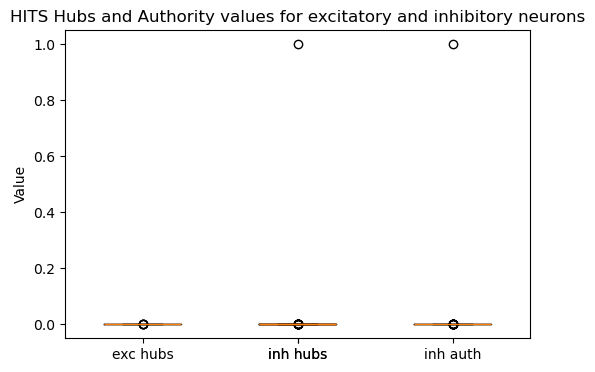

In [61]:
h, a = nx.hits(G)
exc_ind, inh_ind = ld.get_celltype_label(model_name)
fig, ax = plt.subplots(figsize=(6,4))

x_ticks = []
labels = ['exc','inh']
x_tick_labels = []
for i, idxs in enumerate([exc_ind, inh_ind]):
    ax.boxplot([h[idx] for idx in idxs], positions=[idxs[0]], widths=0.5)
    ax.boxplot([a[idx] for idx in idxs], positions=[idxs[0]+1], widths=0.5)
    x_ticks.append(idxs[0]); x_ticks.append(idxs[0]+1)
    x_tick_labels.append(f'{labels[i]} hubs'); x_tick_labels.append(f'{labels[i]} auth')
ax.set_xticks(x_ticks) 
ax.set_xticklabels(x_tick_labels)
ax.set_ylabel('Value')
ax.set_title('HITS Hubs and Authority values for excitatory and inhibitory neurons')
plt.show()

## Closeness Centrality

In [51]:
def closeness_bellman_ford(G, node):
    # Get shortest path lengths from node using Bellman-Ford
    lengths = nx.single_source_bellman_ford_path_length(G, node, weight='weight')
    total = sum(lengths.values())
    if total > 0.0 and len(G) > 1:
        return (len(lengths) - 1) / total
    else:
        return 0.0


In [54]:
# Compute closeness centrality for all nodes
closeness = {node: closeness_bellman_ford(G, node) for node in G.nodes()}
print(closeness)

NetworkXUnbounded: Negative cycle detected.